In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split



In [2]:
data = pd.read_csv('PlayTennis.csv')
data.head()

,Outlook,Temperature,Humidity,Wind,Play Tennis
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes


In [3]:
from sklearn.preprocessing import OneHotEncoder , LabelEncoder ,OrdinalEncoder

outlook = OrdinalEncoder()
data['Outlook'] = outlook.fit_transform(data[['Outlook']])

le = LabelEncoder()
for col in data.columns:
    data[col]= le.fit_transform(data[col])

In [4]:
play_encoder = OrdinalEncoder()
data['play'] = play_encoder.fit_transform(data[['Play Tennis']])

In [5]:
data.head()

,Outlook,Temperature,Humidity,Wind,Play Tennis,play
0,2,1,0,1,0,0.0
1,2,1,0,0,0,0.0
2,0,1,0,1,1,1.0
3,1,2,0,1,1,1.0
4,1,0,1,1,1,1.0


In [6]:
x = data.drop(['Play Tennis'], axis = 1)
y = data['Play Tennis']

In [7]:
clf_entropy = DecisionTreeClassifier(criterion="entropy", random_state=42)
clf_entropy.fit(x,y)
y_pred = clf_entropy.predict(x)


In [8]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [9]:
print("accuracy_score", accuracy_score(y, y_pred))
print("", classification_report(y, y_pred))
print("", confusion_matrix(y, y_pred))

accuracy_score 1.0
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00         9

    accuracy                           1.00        14
   macro avg       1.00      1.00      1.00        14
weighted avg       1.00      1.00      1.00        14

 [[5 0]
 [0 9]]


[Text(0.5, 0.75, 'play <= 0.5\nentropy = 0.94\nsamples = 14\nvalue = [5, 9]\nclass = yes'),
 Text(0.25, 0.25, 'entropy = 0.0\nsamples = 5\nvalue = [5, 0]\nclass = no'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'entropy = 0.0\nsamples = 9\nvalue = [0, 9]\nclass = yes'),
 Text(0.625, 0.5, '  False')]

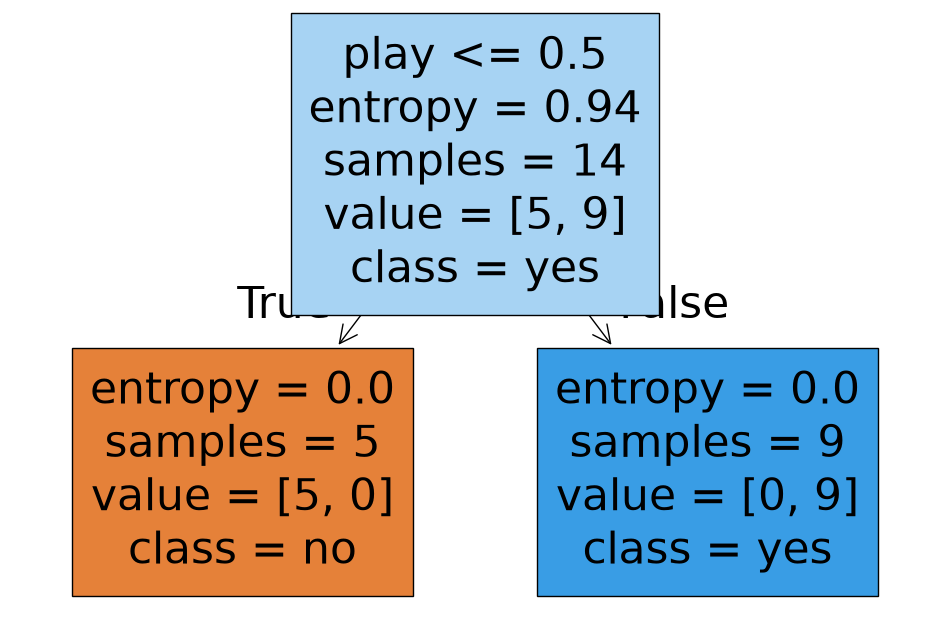

In [10]:
from sklearn import tree
plt.figure(figsize=(12,8))
tree.plot_tree(clf_entropy, feature_names=x.columns, class_names=['no','yes'], filled=True)